# 01 · Обзор данных

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from metrics import load_tables, TICKRATE

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3})

throws, flash_victims, damage, players = load_tables()
pd.DataFrame(
    {"строк": [len(throws), len(flash_victims), len(damage), len(players)]},
    index=["throws", "flash_victims", "damage", "players"],
)

,строк
throws,2385417
flash_victims,1001026
damage,559791
players,99921


## 1. Таблицы и поля

| Таблица | 1 строка = | Ключевые поля |
|---|---|---|
| `throws` | граната | `type` (smoke/flash/he/fire), `side` (T/CT), `round`, `thrower_id`, `throw_x/y/z` — где стоял, `view_yaw/pitch` — куда смотрел, `crouch`, `airborne` — присел / в прыжке, `land_x/y/z` — где сработала, `start_tick/end_tick` |
| `flash_victims` | ослеплённый игрок | `victim` (self/team/enemy), `duration` (сек), `pos_*`, `view_*` — взгляд жертвы, `killed`, `killed_by` |
| `damage` | тик урона от HE или огня | `victim`, `hp`, `armor`, `pos_*`, `killed` |
| `players` | игрок в матче | `rating` — Premier-рейтинг (если есть) |

Связь таблиц: `grenade_id` (граната), `match_id` + `player_id` (игрок).

In [2]:
throws.head(3)

,grenade_id,match_id,round,type,thrower_id,side,start_tick,end_tick,throw_x,throw_y,throw_z,view_yaw,view_pitch,crouch,airborne,vel_x,vel_y,vel_z,land_x,land_y,land_z
0,0,3831383152580887235,6,smoke,472650908,T,36414,36751,2753.308594,79.143608,1646.34375,174.185486,-14.467285,False,True,-244.203125,19.703125,205.0,2.837089,392.758820,1614.030884
1,1,3831383152580887235,2,smoke,747977579,CT,12946,13095,-354.943481,16.869053,1664.03125,12.256287,2.804596,False,False,243.501953,26.866211,0.0,1073.333374,301.014374,1614.031250
2,2,3831383152580887235,2,smoke,1268593003,CT,13193,13328,-547.049500,-924.635010,1612.03125,16.375122,3.031540,False,False,235.619141,67.144531,0.0,416.727966,-596.892334,1614.031250


In [3]:
flash_victims.head(3)

,grenade_id,match_id,round,player_id,side,victim,duration,existing_duration,pos_x,pos_y,pos_z,view_yaw,view_pitch,killed,killed_by,kill_tick,open_kill,remaining_duration
0,72,3831383152580887235,2,747977579,CT,enemy,4.816136,1.37234,570.460510,89.960800,1618.882202,33.248749,0.906372,False,<NA>,<NA>,False,NaN
1,72,3831383152580887235,2,472650908,T,team,0.979625,0.00000,901.663269,221.876465,1612.031250,-51.966370,-2.323273,False,<NA>,<NA>,False,NaN
2,72,3831383152580887235,2,1060982537,CT,enemy,3.554381,0.00000,-310.662964,385.635193,1666.359375,6.382370,-0.337494,False,<NA>,<NA>,False,NaN


In [4]:
damage.head(3)

,grenade_id,match_id,round,type,player_id,side,victim,tick,hp,armor,pos_x,pos_y,pos_z,killed
0,138,3831383152580887235,1,he,747977579,CT,enemy,9883,4,0,-830.442383,911.874390,1716.004028,True
1,138,3831383152580887235,1,he,1249640336,CT,enemy,9883,5,3,-952.049377,837.451233,1658.899292,False
2,141,3831383152580887235,6,he,1231989084,T,enemy,37672,10,0,832.031311,469.943329,1612.031250,False


## 2. Покрытие: матчи, раунды, игроки

матчей: 10,000 | с гранатами: 9,984
уникальных игроков: 90,829 | 1 матч: 92% | ≥3 матчей: 1,444 | ≥5: 165


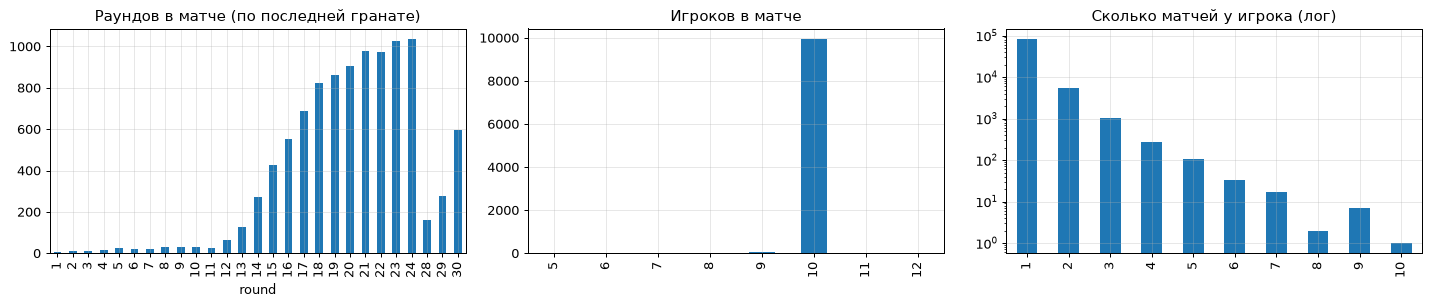

In [5]:
rounds_per_match = throws.groupby("match_id")["round"].max() + 1
players_per_match = players.groupby("match_id").size()
matches_per_player = players.groupby("player_id").size()

fig, ax = plt.subplots(1, 3, figsize=(16, 3.5))
rounds_per_match.value_counts().sort_index().plot.bar(ax=ax[0], title="Раундов в матче (по последней гранате)")
players_per_match.value_counts().sort_index().plot.bar(ax=ax[1], title="Игроков в матче")
matches_per_player.value_counts().sort_index().plot.bar(ax=ax[2], logy=True, title="Сколько матчей у игрока (лог)")
plt.tight_layout()

print(f"матчей: {players.match_id.nunique():,} | с гранатами: {throws.match_id.nunique():,}")
print(f"уникальных игроков: {len(matches_per_player):,} | 1 матч: {(matches_per_player == 1).mean():.0%} | ≥3 матчей: {(matches_per_player >= 3).sum():,} | ≥5: {(matches_per_player >= 5).sum():,}")

Раунды 13–24 — обычные матчи MR12 (до 13 побед), 25+ — овертаймы.
**92% игроков встречаются в одном матче** — длинной истории игроков в датасете нет (важно для персонализации).

## 3. Рейтинг Premier

записей игроков с рейтингом: 24.4%
матчей, где рейтинга нет ни у кого: 1,814
матчей, где рейтинг у всех 10: 10


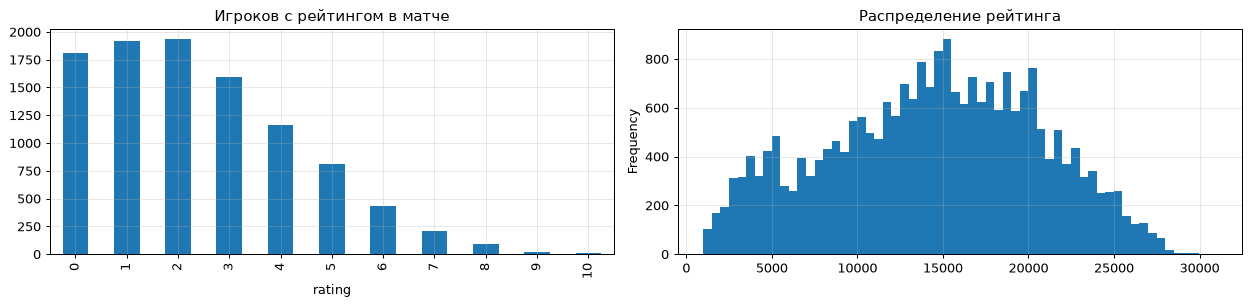

In [6]:
rated_per_match = players.groupby("match_id").rating.count()

fig, ax = plt.subplots(1, 2, figsize=(14, 3.5))
rated_per_match.value_counts().sort_index().plot.bar(ax=ax[0], title="Игроков с рейтингом в матче")
players.rating.dropna().astype(float).plot.hist(bins=60, ax=ax[1], title="Распределение рейтинга")
plt.tight_layout()

print(f"записей игроков с рейтингом: {players.rating.notna().mean():.1%}")
print(f"матчей, где рейтинга нет ни у кого: {(rated_per_match == 0).sum():,}")
print(f"матчей, где рейтинг у всех 10: {(rated_per_match >= 10).sum():,}")

Рейтинг есть только у ~¼ игроков, и почти никогда у всех 10 в матче. Похоже, рейтинг виден лишь у части игроков
(ММ-матчи, скрытый рейтинг) — **по рейтингу можно сравнивать только на подвыборке**.

## 4. Качество данных

In [7]:
# z < 1500 — явно битые координаты на карте
checks = {
    "матчи без гранат": players.match_id.nunique() - throws.match_id.nunique(),
    "броски с z<1500 (битые позиции)": int((throws.throw_z < 1500).sum()),
    "позиции ослеплённых с z<1500": int((flash_victims.pos_z < 1500).sum()),
    "матчи, где первая граната не в раунде 0": int((throws.groupby("match_id")["round"].min() > 0).sum()),
    "урон по своим / себе (HE, огонь)": int((damage.victim != "enemy").sum()),
    "ослепления своих / себя": int((flash_victims.victim != "enemy").sum()),
}
pd.Series(checks, name="кол-во").to_frame()

,кол-во
матчи без гранат,16
броски с z<1500 (битые позиции),0
позиции ослеплённых с z<1500,676
"матчи, где первая граната не в раунде 0",1503
"урон по своим / себе (HE, огонь)",0
ослепления своих / себя,517938


- **Урона по своим в данных нет вообще** — записан только урон по врагам. Оценить «HE по своим» нельзя.
- Ослепления своих при этом есть — для флешек «вред своим» считается.
- Битых позиций доли процента — отбрасываем при построении карты.
- В ~15% матчей нет гранат в раунде 0. Почти всегда первая граната в раунде 1 — в пистолетных раундах гранат мало
  (в среднем 3.7 на раунд против 12.6 в остальных), так что это скорее норма, чем потеря данных.

## 5. Проверка смысла полей

In [8]:
throws["flight_sec"] = (throws.end_tick - throws.start_tick) / TICKRATE
throws.groupby("type", observed=True).flight_sec.describe(percentiles=[0.05, 0.5, 0.95]).round(2)

,count,mean,std,min,5%,50%,95%,max
type,,,,,,,,
fire,446164.0,1.37,0.39,0.02,0.77,1.33,2.02,4.20
flash,643914.0,1.62,0.02,0.02,1.62,1.62,1.62,1.70
he,565392.0,1.62,0.03,0.00,1.62,1.62,1.62,1.72
smoke,729947.0,2.85,1.37,0.05,1.39,2.45,5.72,14.53


У флешки и HE запал ~1.6 с → `end_tick` — момент срабатывания; время полёта по типам согласуется с этим.

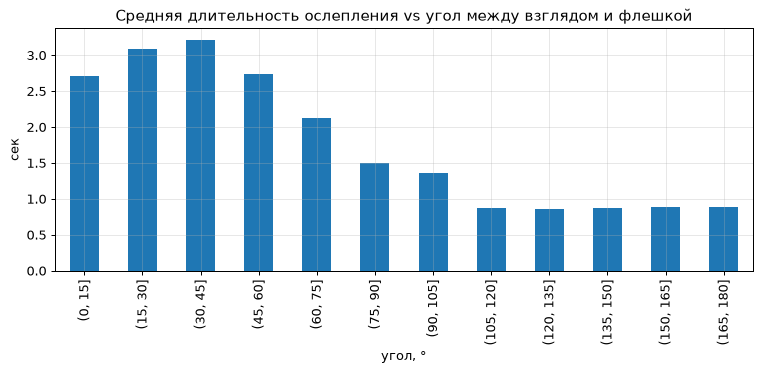

In [9]:
flashes = flash_victims.merge(throws[["grenade_id", "land_x", "land_y"]], on="grenade_id")
bearing_to_flash = np.degrees(np.arctan2(flashes.land_y - flashes.pos_y, flashes.land_x - flashes.pos_x))
# угол между взглядом жертвы и направлением на флешку, 0° = смотрит на взрыв
flashes["angle"] = ((bearing_to_flash - flashes.view_yaw + 180) % 360 - 180).abs()

ax = flashes.groupby(pd.cut(flashes.angle, range(0, 181, 15)), observed=True).duration.mean().plot.bar(
    figsize=(10, 3.5), title="Средняя длительность ослепления vs угол между взглядом и флешкой",
)
ax.set_xlabel("угол, °")
ax.set_ylabel("сек")

Подтверждено для `view_yaw`: прямой взгляд на флешку — ~2.8 с, спиной — <1 с.

## 6. Техника броска

In [10]:
throws.groupby("type", observed=True)[["crouch", "airborne"]].mean().mul(100).round(1).rename(
    columns={"crouch": "присел, %", "airborne": "в прыжке, %"},
)

,"присел, %","в прыжке, %"
type,,
fire,1.4,3.7
flash,3.1,14.0
he,2.0,3.1
smoke,1.7,15.5


Смоки и флешки бросают в прыжке в 4–5 раз чаще, чем HE и молотовы: это заученные раскидки (jump-throw).

## Итог: что есть и чего нет

| Есть | Нет |
|---|---|
| откуда / как / куда брошена каждая граната | итог раунда и матча |
| кого и на сколько ослепила флешка (включая своих) | начала раунда (только порядок и интервалы) |
| урон и убийства от HE и огня **по врагам** | урона по своим, позиций игроков во времени, экономики |
| рейтинг Premier (у ~¼ игроков) | контура огня (0.4%), декоев, результата смоков |